In [1]:
import json
with open('ChatGLM/train/train_result.json','r',encoding='utf-8') as file:
    data = json.load(file)

In [2]:
def calculate_precision(data):
    true_positives = 0
    predicted_positives = 0

    for entry in data:
        input = entry["instruction"]
        response =entry['target']
        prediction =entry['prediction']

        #print(prediction)
        if response == prediction:
            true_positives += 1
        else:
            print(input)
            print("response:",response)
            print("prediction:",prediction)
        if prediction:  # Count all instances where prediction is positive
            predicted_positives += 1

    precision = true_positives / predicted_positives
    return precision

# 计算准确率
precision = calculate_precision(data)
print("Precision:", precision)


### 指令:
下述提供了user demand，target feature以及options。user demand为user对于一个或多个feature的描述。根据user demand推测并在options中选择一个最适合target feature的值。若推测的值不明确，则结果为None。

### 输入:
user demand:'''我想找一个地方，面积大概在七百平方米左右吧，最好是在简阳区的。'''
target feature:#面积#
options:
'''['<100m²', '100-300m²', '300-500m²', '500-1000m²', '1000-5000m²', '>5000m²']'''
response: [{'key': '面积', 'value': '500-1000m²'}]
prediction: [{'key': '面积', 'value': '500-1000m2'}]
### 指令:
下述提供了user demand，target feature以及options。user demand为user对于一个或多个feature的描述。根据user demand推测并在options中选择一个最适合target feature的值。若推测的值不明确，则结果为None。

### 输入:
user demand:'''我想找一个面积比较大的房子，大概在3000平方米左右，最好在双流区的。'''
target feature:#面积#
options:
'''['<100m²', '100-300m²', '300-500m²', '500-1000m²', '1000-5000m²', '>5000m²']'''
response: [{'key': '面积', 'value': '1000-5000m²'}]
prediction: [{'key': '面积', 'value': '1000-5000m2'}]
### 指令:
下述提供了user demand，target feature以及options。user demand为user对于一个或多个feature的描述。根据user demand推测并在options中选择一个最适合target feature的值。若推测的值不明确，则结果为None。

In [3]:
import json
from nltk.translate.bleu_score import sentence_bleu

def calculate_bleu(data):
    bleu_data = []  # 存储每个数据的 BLEU 分数和数据本身

    for entry in data:
        response = entry['target']
        prediction = entry['prediction']
        reference = [response.split()]
        prediction = prediction.split()
        # 计算 BLEU 分数
        bleu_1 = sentence_bleu(reference, prediction,weights=(1,0,0,0))
        bleu_2 = sentence_bleu(reference, prediction,weights=(0.5,0.5,0,0))
        bleu_3 = sentence_bleu(reference, prediction,weights=(0.33,0.33,0.33,0))
        bleu_4 = sentence_bleu(reference, prediction,weights=(0.25,0.25,0.25,0.25))
        # 存储 BLEU 分数和数据
        bleu_data.append((bleu_1,bleu_2,bleu_3,bleu_4, entry))
    return bleu_data

# 计算每条数据的 BLEU 分数和数据
bleu_scores = calculate_bleu(data)

outputs=[]
index=0
for bleu_1,bleu_2,bleu_3,bleu_4, entry in bleu_scores:
    outputs.append({

        "Cumulative 1-gram":bleu_1,
        "Cumulative 2-gram":bleu_2,
        "Cumulative 3-gram":bleu_3,
        "Cumulative 4-gram":bleu_4,
        "data":entry
    })
    index+=1
formate_datas=[]
# 将 BLEU 分数和对应的数据保存到文件
with open('scores_train.json', 'w', encoding='utf-8') as f:
    f.write('[')
    for output in outputs:
        res=json.dumps(output, indent=4,ensure_ascii=False)
        f.write(res)
        if output!=outputs[len(outputs)-1]:
            f.write(',')
    f.write(']')

avg_bleu_1 = sum(bleu_1 for bleu_1,bleu_2,bleu_3,bleu_4, _ in bleu_scores) / len(bleu_scores)
print("Average BLEU Score 1-gram:", avg_bleu_1)
avg_bleu_2 = sum(bleu_2 for bleu_1,bleu_2,bleu_3,bleu_4, _ in bleu_scores) / len(bleu_scores)
print("Average BLEU Score 2-gram:", avg_bleu_2)
avg_bleu_3 = sum(bleu_3 for bleu_1,bleu_2,bleu_3,bleu_4, _ in bleu_scores) / len(bleu_scores)
print("Average BLEU Score 3-gram:", avg_bleu_3)
avg_bleu_4 = sum(bleu_4 for bleu_1,bleu_2,bleu_3,bleu_4, _ in bleu_scores) / len(bleu_scores)
print("Average BLEU Score 4-gram:", avg_bleu_4)

E:\Anaconda3\envs\d2l\lib\site-packages\nltk\translate\bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


Average BLEU Score 1-gram: 0.9899866981968667
Average BLEU Score 2-gram: 0.9882686872157213
Average BLEU Score 3-gram: 0.9852955983569223
Average BLEU Score 4-gram: 0.9599467927874668


#### 计算损失函数

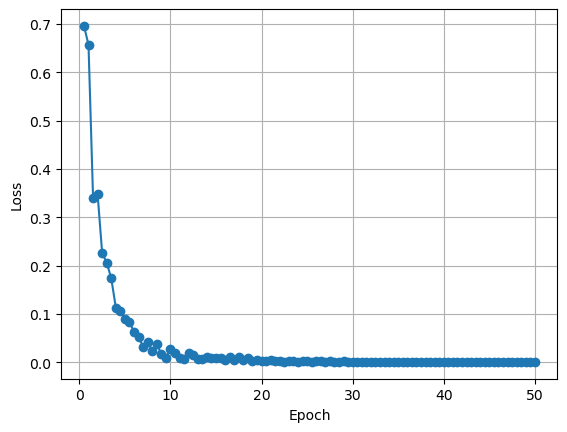

In [2]:
import json
import matplotlib.pyplot as plt

# 读取JSON数据
data_path = "./output/loss.json"
with open(data_path, "r") as f:
    data = json.load(f)

# 提取epoch和loss
epochs = [entry["epoch"] for entry in data]
losses = [entry["loss"] for entry in data]

# 绘制图表
plt.plot(epochs, losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()